# Exercises
_Rijcklof Hofman s4792432_

In [13]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn import svm
import numpy as np
import pickle
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

#donwload lesson data
download_data('https://surfdrive.surf.nl/s/NrNbvEOH7SImYLn')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import ipywidgets as widgets
from ipywidgets import interact

In [6]:
with open('data/simulated_data1.pickle', 'rb') as handle:
    data = pickle.load(handle)

spike_times = data['spike_times']
stim_onsets = data['stim_onsets']
stim_type = data['stim_type']
stim_duration = data['stim_duration']

### Exercise 1
---
Use the sklearn `make_blobs()` function, in the same way that we used in the lesson, to generate a *non linearly separable* dataset with 2 features.  
Fit a linear SVM to the dataset many times, varying the slack hyperparameter $C$, and calculate the model performance in classifying the data.  
What is, approximately, a the best value of the $C$ hyperparameter for this dataset?

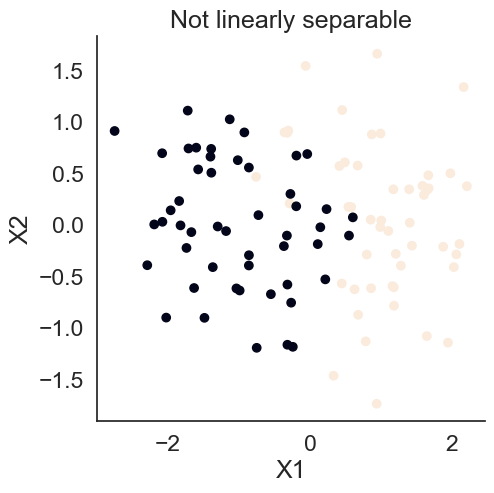

In [12]:
X,y = make_blobs(n_samples=100,n_features=2,centers=[[-1,0],[1,0]],cluster_std=.8)
plt.figure(figsize=(5,5))
plt.title('Not linearly separable')
plt.xlabel('X1')
plt.ylabel('X2')
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [32]:
Cs = np.linspace(0.1,4.,num=40)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances = []
for C in Cs:
    svc_model = svm.SVC(kernel='linear',C=C);
    svc_model.fit(X_train, y_train)
    performances.append(svc_model.score(X_test,y_test))

performances = np.array([performances])



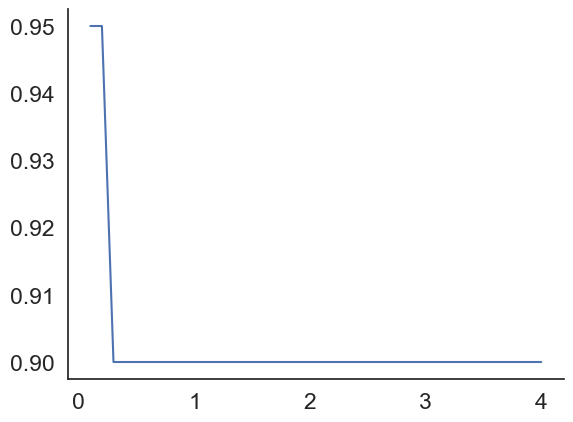

In [33]:
plt.plot(Cs,performances[0])
plt.show()

This indicates that C has to be small.

A closer look at small C's gives:

In [30]:
Cs_2 = np.linspace(0.001,.5,num=40)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_2 = []
for C in Cs_2:
    svc_model = svm.SVC(kernel='linear',C=C);
    svc_model.fit(X_train, y_train)
    performances_2.append(svc_model.score(X_test,y_test))

performances_2 = np.array([performances_2])

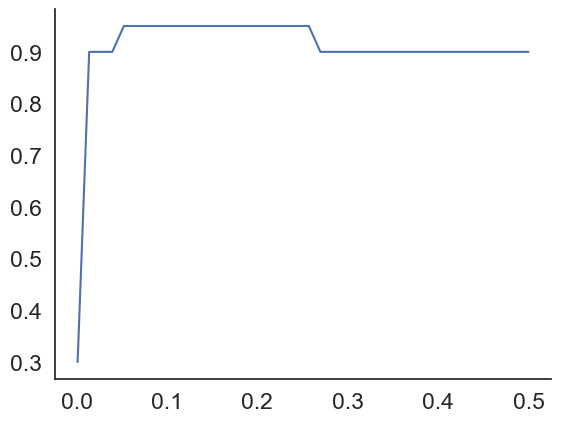

In [31]:
plt.plot(Cs_2,performances_2[0])
plt.show()

Zooming in again

In [36]:
Cs_3 = np.linspace(0.01,.03,num=80)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_3 = []
for C in Cs_3:
    svc_model = svm.SVC(kernel='linear',C=C);
    svc_model.fit(X_train, y_train)
    performances_3.append(svc_model.score(X_test,y_test))

performances_3 = np.array([performances_3])

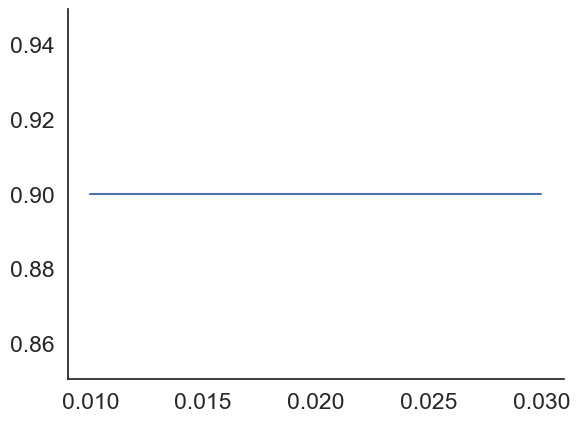

In [37]:
plt.plot(Cs_3,performances_3[0])
plt.show()

The optimum value for $C$ seems to be between $0.01$ and $0.03$.

### Exercise 2
---
Repeat exercise 1, but using a non-linear SVM model (the sklearn class `SVC` uses [Radial Basis Functions](https://en.wikipedia.org/wiki/Radial_basis_function) as a default, check its documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)). 
To have a fairer assessment of the performance, train the model on a fraction (e.g. 80%) of the data, and test it on the other 20%.
Compare the performance of a linear SVC and a RBF SVC for dataset that are increaslingly non-linearly-separable.


In [39]:
Cs_r = np.linspace(0.1,4.,num=40)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_r = []
for C in Cs_r:
    svc_model = svm.SVC(kernel='rbf',C=C);
    svc_model.fit(X_train, y_train)
    performances_r.append(svc_model.score(X_test,y_test))

performances_r = np.array([performances_r])


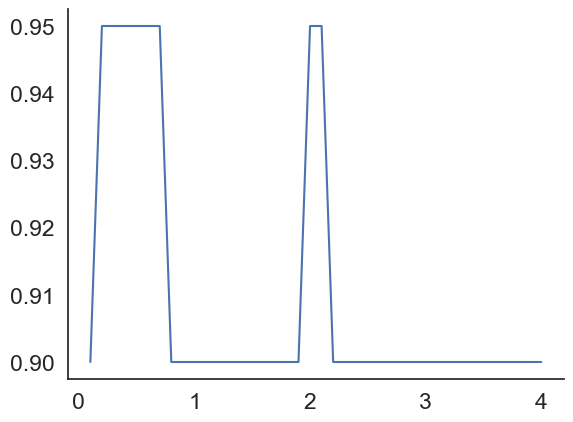

In [40]:
plt.plot(Cs_r,performances_r[0])
plt.show()

The optimum seems to be either between $0$ and $1$, or between $2$ and $2.5$.
Let's have a closer look

In [43]:
Cs_r2 = np.linspace(0.001,1.,num=40)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_r2 = []
for C in Cs_r2:
    svc_model = svm.SVC(kernel='rbf',C=C);
    svc_model.fit(X_train, y_train)
    performances_r2.append(svc_model.score(X_test,y_test))

performances_r2 = np.array([performances_r2])

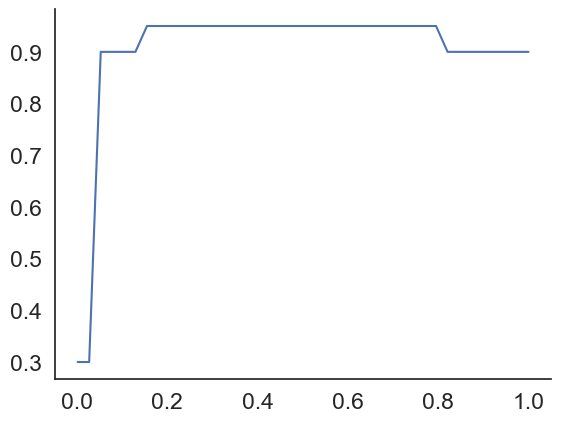

In [47]:
plt.plot(Cs_r2,performances_r2[0])
plt.show()

In [45]:
Cs_r3 = np.linspace(1.99,2.51,num=40)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_r3 = []
for C in Cs_r3:
    svc_model = svm.SVC(kernel='rbf',C=C);
    svc_model.fit(X_train, y_train)
    performances_r3.append(svc_model.score(X_test,y_test))

performances_r3 = np.array([performances_r3])

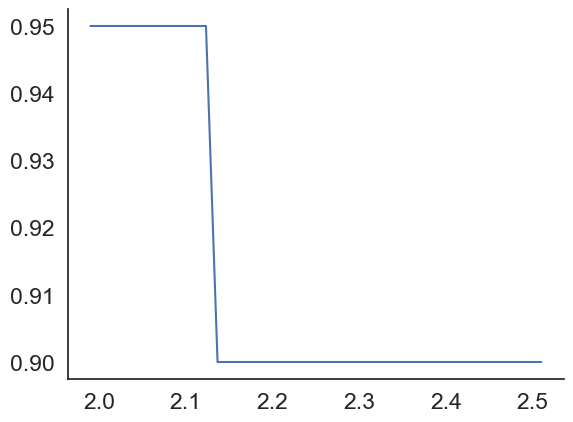

In [48]:
plt.plot(Cs_r3,performances_r3[0])
plt.show()

Zooming in again

In [65]:
Cs_r4 = np.linspace(.125,.8,num=80)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_r4 = []
for C in Cs_r4:
    svc_model = svm.SVC(kernel='rbf',C=C);
    svc_model.fit(X_train, y_train)
    performances_r4.append(svc_model.score(X_test,y_test))

performances_r4 = np.array([performances_r4])

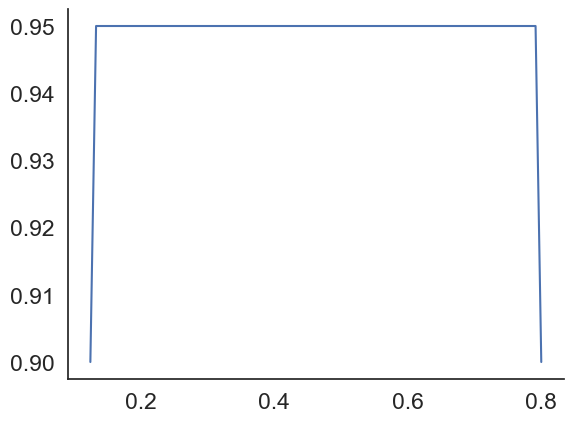

In [66]:
plt.plot(Cs_r4,performances_r4[0])
plt.show()

In [59]:
Cs_r5 = np.linspace(1.99,2.13,num=80)
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

performances_r5 = []
for C in Cs_r5:
    svc_model = svm.SVC(kernel='rbf',C=C);
    svc_model.fit(X_train, y_train)
    performances_r5.append(svc_model.score(X_test,y_test))

performances_r5 = np.array([performances_r5])

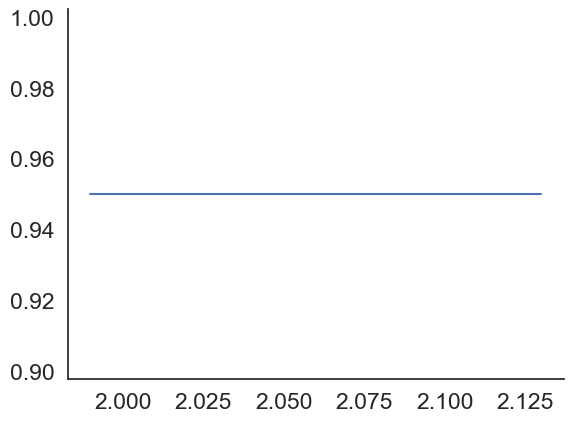

In [60]:
plt.plot(Cs_r5,performances_r5[0])
plt.show()

The optimum for C seems to be either between $0.125$ and $0.8$ or between $1.99$ and $2.125$.

### Exercise 3
---
Use the code below to simulate new data.
Generate data and then decode the stimulus identity, see how the decoding performance change when you change the following:

- The amplitude of the noise in the firing rate
- The amplitude of the stimulus modulation of the firing rate
- The number of neurons

Plot and comment.

## Useful code
---


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [4]:
n_cells = 20; # number of cells to simulate
n_stim_type = 2; # number of different stimuli
sigma_stim = 0.5 # amplitude of stimulus related modulation
average_firing_rate = 5; # average firing rate across the population

# generate baseline rates from exponential distirbution
cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

# create stimulus average responses, perturbing the population firng rate profile
# we use a multiplicative modulation in opposite directions for the two stimuli
modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
# sets negative firng rate to 0
cell_rate_stim[1][cell_rate_stim[1]<0]=0
cell_rate_stim[2][cell_rate_stim[2]<0]=0

In [5]:
# simulate spiking activity

s_rate = 10000 # the sampling rate of our emulated recording system
noise_rate = 1 # we are going to add some spike noise non related to the task
n_stim = 100 # number of stimuli

stim_dur = 2 #stimulus duration (in seconds)
is_interval = 3 # interval between stimuli  (in seconds)

stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
np.random.shuffle(stim_type)

time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

spike_times = []
for cell in range(n_cells):
    spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
    for i,stimulus in enumerate(stim_type):
        stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
        spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

    spike_times.append(time[spikes>0])



In [73]:
# save ouput
out_dict = {'spike_times':spike_times,
            'stim_onsets':stim_onsets,
            'stim_type':stim_type,
            'stim_duration':stim_dur
            }

with open('data/simulated_data1.pickle', 'wb') as handle:
    pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)
